<a href="https://colab.research.google.com/github/YuriFla94/Processamento-de-Sinais-1/blob/main/Tarefa4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

QUESTÃO 1

# Comparação entre DTFT e DFT usando Matrizes
Este notebook apresenta a comparação prática entre a Transformada de Fourier de Tempo Discreto (DTFT) e a Transformada Discreta de Fourier (DFT) para o sinal:
$$x[n] = \delta[n] - \delta[n-1] + \delta[n-2] - \delta[n-3]$$

A DFT será calculada matricialmente utilizando a função `scipy.linalg.dft`.

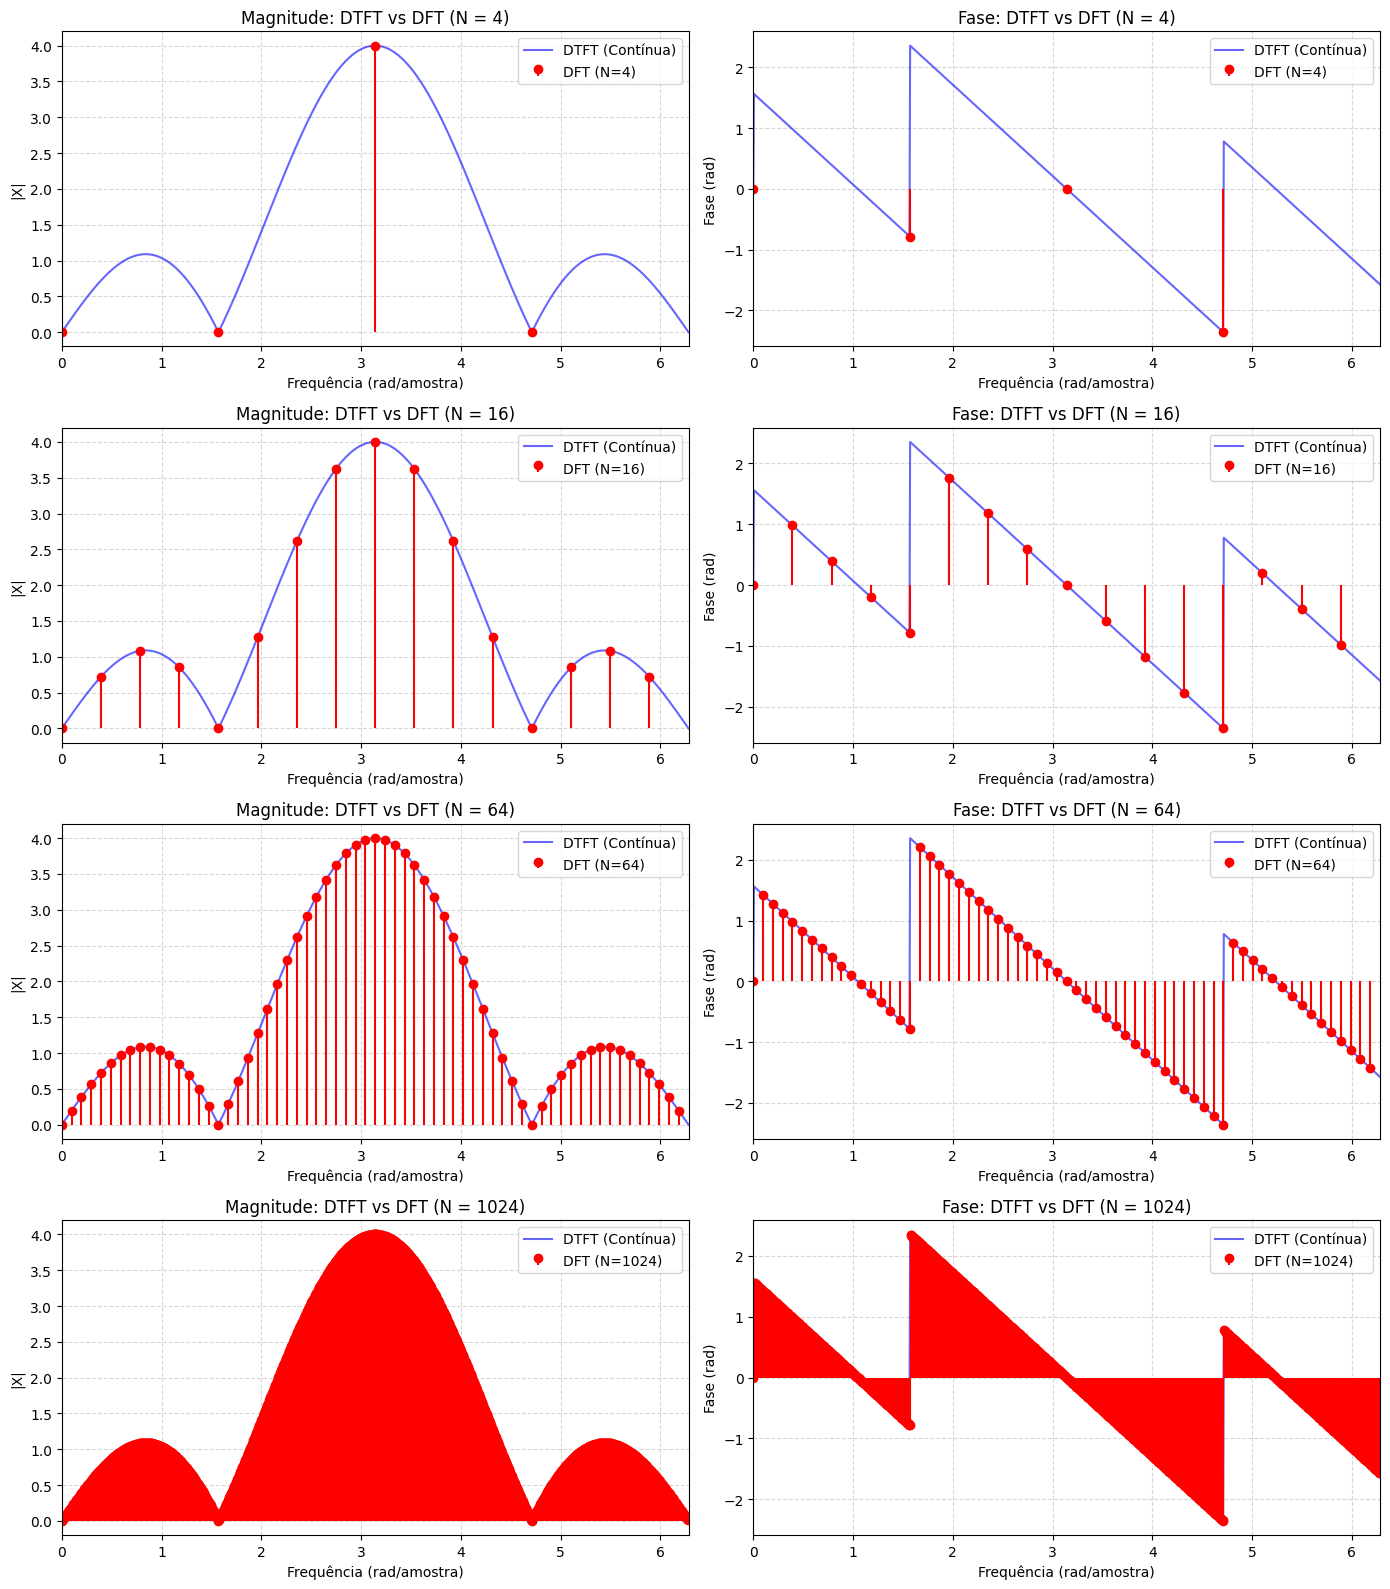

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import dft

# 1. Definindo a DTFT analítica do sinal x[n]
def dtft_x(omega):
    # x[n] = [1, -1, 1, -1] para n = 0, 1, 2, 3
    return 1 - np.exp(-1j * omega) + np.exp(-2j * omega) - np.exp(-3j * omega)

# Valores de N para avaliação
N_values = [4, 16, 64, 1024]

# Configuração da figura
fig, axes = plt.subplots(len(N_values), 2, figsize=(14, 16))

# Eixo de frequências contínuas para a DTFT (de 0 a 2*pi)
omega_continuous = np.linspace(0, 2 * np.pi, 1000)
X_dtft = dtft_x(omega_continuous)

for i, N in enumerate(N_values):
    # 2. Construindo o vetor x[n] com zero-padding até o comprimento N
    x = np.zeros(N)
    x[0:4] = [1, -1, 1, -1]

    # 3. Construindo a matriz DFT de ordem N utilizando scipy.linalg.dft
    # Nota: scipy.linalg.dft implementa a matriz W_N de modo que X = D_N @ x
    D_N = dft(N)

    # 4. Cálculo da DFT via multiplicação matricial
    X_dft = D_N @ x

    # Frequências discretas correspondentes aos bins da DFT: w_k = 2 * pi * k / N
    omega_discrete = np.arange(N) * (2 * np.pi / N)

    # --- Plot da Magnitude ---
    ax_mag = axes[i, 0]
    ax_mag.plot(omega_continuous, np.abs(X_dtft), label='DTFT (Contínua)', color='blue', alpha=0.6)
    ax_mag.stem(omega_discrete, np.abs(X_dft), linefmt='red', markerfmt='ro', basefmt=' ', label=f'DFT (N={N})')
    ax_mag.set_title(f'Magnitude: DTFT vs DFT (N = {N})')
    ax_mag.set_xlabel('Frequência (rad/amostra)')
    ax_mag.set_ylabel('|X|')
    ax_mag.set_xlim(0, 2 * np.pi)
    ax_mag.grid(True, linestyle='--', alpha=0.5)
    ax_mag.legend()

    # --- Plot da Fase ---
    ax_phase = axes[i, 1]
    ax_phase.plot(omega_continuous, np.angle(X_dtft), label='DTFT (Contínua)', color='blue', alpha=0.6)
    ax_phase.stem(omega_discrete, np.angle(X_dft), linefmt='red', markerfmt='ro', basefmt=' ', label=f'DFT (N={N})')
    ax_phase.set_title(f'Fase: DTFT vs DFT (N = {N})')
    ax_phase.set_xlabel('Frequência (rad/amostra)')
    ax_phase.set_ylabel('Fase (rad)')
    ax_phase.set_xlim(0, 2 * np.pi)
    ax_phase.grid(True, linestyle='--', alpha=0.5)
    ax_phase.legend()

plt.tight_layout()
plt.show()

### Análise e Comentários sobre os Resultados

1. **Amostragem da DTFT:**
   A DFT é conceitualmente a versão amostrada na frequência da DTFT. As frequências em que a DFT avalia o espectro são dadas por $\omega_k = \frac{2\pi k}{N}$ para $k = 0, 1, \dots, N-1$.

2. **Efeito do Tamanho de $N$:**
   * **Para $N = 4$:** O número de pontos da DFT coincide exatamente com a duração do sinal original. Temos apenas 4 amostras do espectro. Embora capturemos os valores exatos nessas frequências específicas, a resolução espectral é extremamente baixa e não conseguimos visualizar o comportamento ondulatório contínuo da DTFT.
   * **Para $N = 16$ e $N = 64$:** Ao aumentarmos o tamanho da matriz DFT (com a técnica de *zero-padding* no sinal temporal), aumentamos a quantidade de pontos amostrados na frequência. O contorno da magnitude e da fase da DTFT começa a se revelar claramente.
   * **Para $N = 1024$:** A quantidade de bins da DFT é tão densa que a representação discreta se torna visualmente idêntica à curva contínua da DTFT. Isso demonstra na prática que a DFT com alto índice de *zero-padding* serve como uma excelente aproximação computacional para visualizar a DTFT contínua.

QUESTÃO 2

## Questão 2: Impacto do Tamanho da DFT na Resolução Espectral

Nesta seção, analisamos o sinal $x(t) = \sin(2\pi t) + \sin(2.2\pi t)$ amostrado com $f_s = 10\text{ Hz}$ para entender a diferença entre aumentar o tempo de observação (número real de amostras) e realizar o preenchimento com zeros (*zero-padding*).

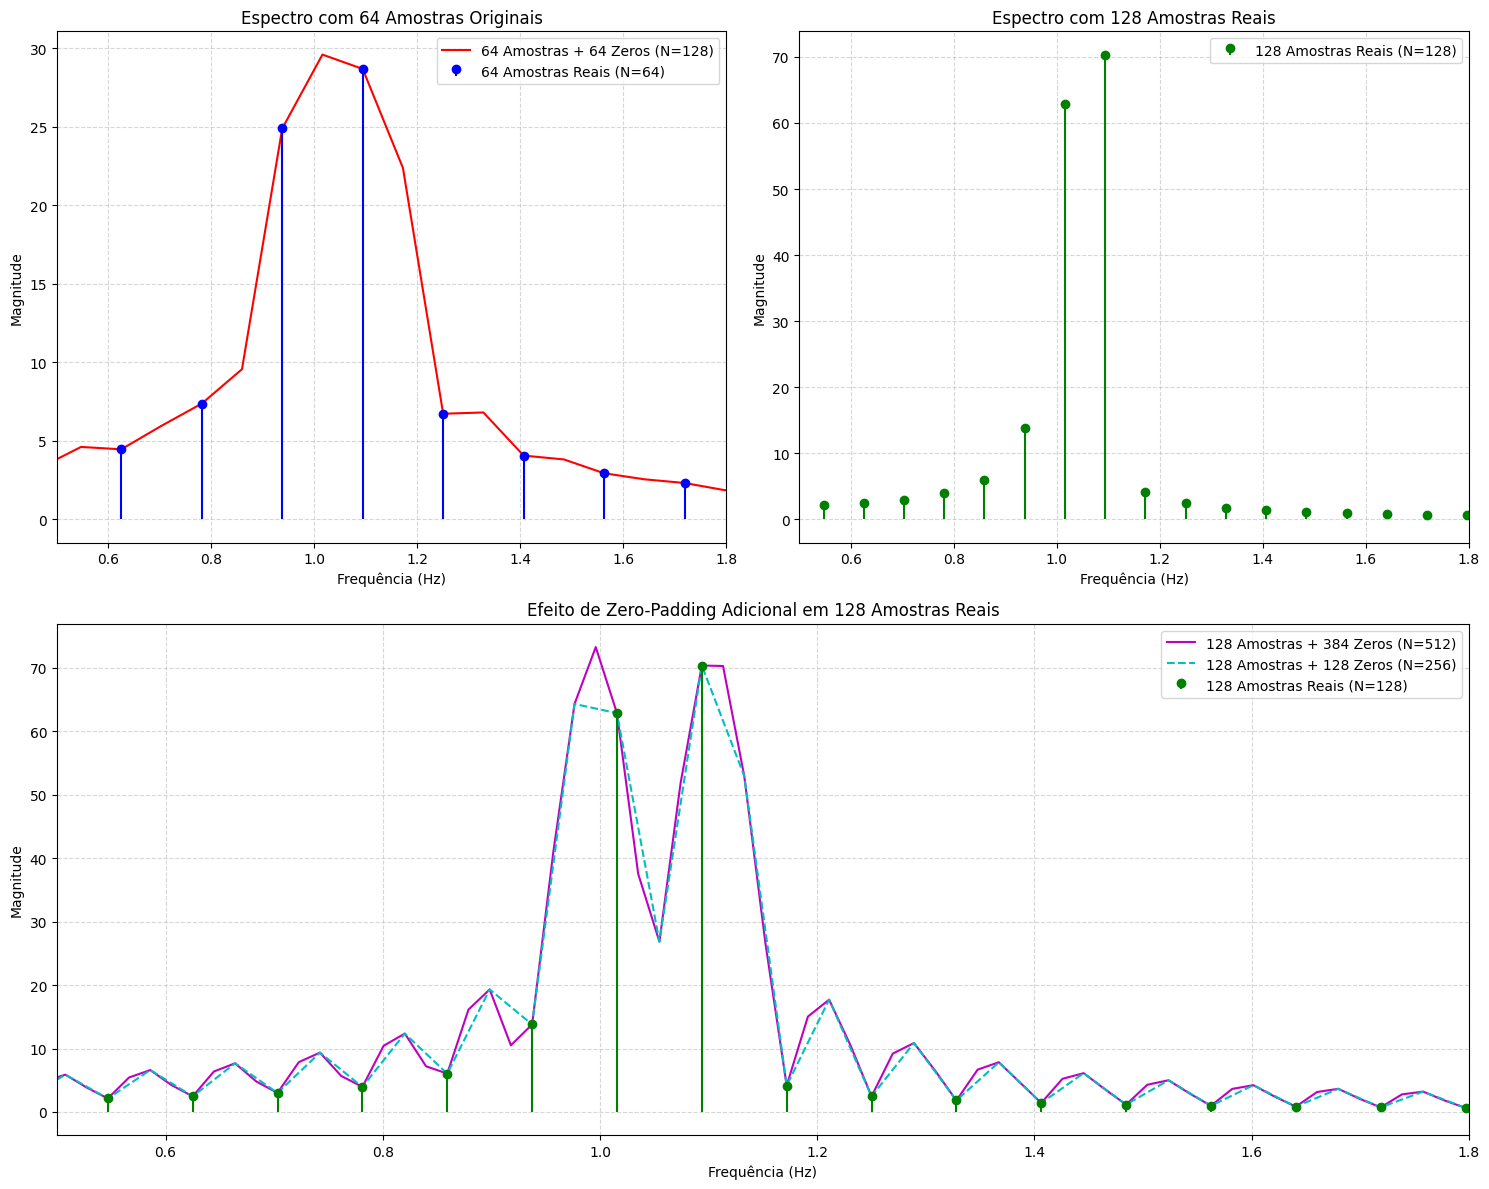

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parâmetros do sinal
fs = 10.0       # Frequência de amostragem
Ts = 1.0 / fs   # Período de amostragem

# Função para gerar o sinal amostrado
def gerar_sinal(N_amostras):
    n = np.arange(N_amostras)
    t = n * Ts
    return n, np.sin(2 * np.pi * t) + np.sin(2.2 * np.pi * t)

# 1. Caso A: 64 amostras reais
n_64, x_64 = gerar_sinal(64)

# 2. Caso B: 64 amostras reais + 64 zeros (Zero-padding para N=128)
x_64_pad128 = np.pad(x_64, (0, 64), 'constant')

# 3. Caso C: 128 amostras reais (sem zero-padding)
n_128, x_128 = gerar_sinal(128)

# 4. Caso D: 128 amostras reais + 128 zeros (Zero-padding para N=256)
x_128_pad256 = np.pad(x_128, (0, 128), 'constant')

# 5. Caso E: 128 amostras reais + 384 zeros (Zero-padding para N=512)
x_128_pad512 = np.pad(x_128, (0, 384), 'constant')

# Função auxiliar para calcular e retornar a magnitude da DFT e o eixo em Hz
def calcular_dft(sinal, N_fft, fs):
    X = np.fft.fft(sinal, n=N_fft)
    # Pegamos apenas a metade positiva do espectro
    metade = N_fft // 2
    X_mag = np.abs(X[:metade])
    freqs = np.fft.fftfreq(N_fft, d=1/fs)[:metade]
    return freqs, X_mag

# Plotagem e Comparação
plt.figure(figsize=(15, 12))

# Subplot 1: Comparação de 64 amostras vs 64 amostras + zero-padding
plt.subplot(2, 2, 1)
f_64, X_64 = calcular_dft(x_64, 64, fs)
f_64_pad, X_64_pad = calcular_dft(x_64_pad128, 128, fs)
plt.plot(f_64_pad, X_64_pad, 'r-', label='64 Amostras + 64 Zeros (N=128)')
plt.stem(f_64, X_64, linefmt='b-', markerfmt='bo', basefmt=' ', label='64 Amostras Reais (N=64)')
plt.title('Espectro com 64 Amostras Originais')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0.5, 1.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 2: 128 amostras reais (Sem zero-padding)
plt.subplot(2, 2, 2)
f_128, X_128 = calcular_dft(x_128, 128, fs)
plt.stem(f_128, X_128, linefmt='g-', markerfmt='go', basefmt=' ', label='128 Amostras Reais (N=128)')
plt.title('Espectro com 128 Amostras Reais')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0.5, 1.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Subplot 3: Efeito de zero-padding sobre as 128 amostras reais
plt.subplot(2, 1, 2)
f_128_pad256, X_128_pad256 = calcular_dft(x_128_pad256, 256, fs)
f_128_pad512, X_128_pad512 = calcular_dft(x_128_pad512, 512, fs)
plt.plot(f_128_pad512, X_128_pad512, 'm-', label='128 Amostras + 384 Zeros (N=512)')
plt.plot(f_128_pad256, X_128_pad256, 'c--', label='128 Amostras + 128 Zeros (N=256)')
plt.stem(f_128, X_128, linefmt='g-', markerfmt='go', basefmt=' ', label='128 Amostras Reais (N=128)')
plt.title('Efeito de Zero-Padding Adicional em 128 Amostras Reais')
plt.xlabel('Frequência (Hz)')
plt.ylabel('Magnitude')
plt.xlim(0.5, 1.8)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

### Discussão e Análise Conceitual

1. **64 amostras reais (N=64):**
   Com $N = 64$ amostras a uma taxa de $f_s = 10\text{ Hz}$, a janela temporal do sinal é de $T = 6.4\text{ segundos}$. A resolução espectral intrínseca é dada por:
   $$\Delta f_{\text{res}} = \frac{1}{T} = \frac{f_s}{N} = \frac{10}{64} \approx 0.156\text{ Hz}$$
   Como as duas frequências senoidais do sinal estão separadas por apenas $0.1\text{ Hz}$ ($1.0\text{ Hz}$ e $1.1\text{ Hz}$), a diferença entre elas é menor do que a nossa resolução espectral intrínseca ($0.1 < 0.156$). Portanto, **não é possível distinguir as duas componentes**, observando-se apenas um único pico alargado.

2. **Efeito do Zero-Padding (64 Amostras + 64 Zeros):**
   Ao realizar o *zero-padding* para $N = 128$ pontos, a DFT calcula o espectro em mais pontos (amostragem mais densa na frequência). No entanto, a curva vermelha no primeiro gráfico mostra que, embora a linha espectral fique mais suave ("interpolada"), as duas pontas das senoides **ainda continuam indistinguíveis**. O *zero-padding* não melhora a resolução física do sinal; ele apenas melhora o acabamento visual da interpolação matemática.

3. **128 amostras reais (N=128):**
   Ao coletarmos $128$ amostras reais, aumentamos o tempo de observação do sinal para $T = 12.8\text{ segundos}$. Nossa nova resolução espectral é:
   $$\Delta f_{\text{res}} = \frac{10}{128} \approx 0.078\text{ Hz}$$
   Dado que a separação das senoides ($0.1\text{ Hz}$) agora é maior do que a resolução espectral ($0.1 > 0.078$), **as duas senoides se tornam perfeitamente distinguíveis**, apresentando dois picos bem definidos no segundo gráfico.

4. **Zero-Padding adicional sobre as 128 amostras:**
   Ao preencher o sinal de 128 pontos com zeros adicionais para chegar em $N=256$ e $N=512$, o contorno espectral se torna cada vez mais suave, ajudando a identificar com extrema precisão os picos de frequência em exatamente $1.0\text{ Hz}$ e $1.1\text{ Hz}$.

### Conclusão
* **Resolução Espectral Física:** Só pode ser melhorada aumentando o tempo de aquisição de dados real (janela de tempo $T$).
* **Zero-Padding:** Não cria novas informações de resolução. Ele atua apenas como um interpolador ideal na frequência, diminuindo o espaçamento entre as amostras calculadas no gráfico para facilitar a leitura visual.

## Questão 3: Compressão de Áudio via DFT (Sinal `handel.wav`)

Nesta seção, realizamos a compressão do arquivo de áudio `handel.wav` utilizando a eliminação de coeficientes espectrais de menor energia da DFT para obter taxas de conservação de energia de $r \in \{99.5\%, 99.0\%, 90.0\%, 75.0\%, 50.0\%\}$.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import IPython.display as ipd

# 1. Carregar o arquivo de áudio
file_path = '/content/handel.wav'
samplerate, data = wavfile.read(file_path)

# Se o áudio for estéreo, converte para mono pegando apenas um canal
if len(data.shape) > 1:
    signal = data[:, 0].astype(float)
else:
    signal = data.astype(float)

N_total = len(signal)

# 2. Calcular a DFT do sinal original
# Usamos a rfft (FFT para sinais reais) para facilitar a compressão mantendo a simetria conjugada
X_full = np.fft.rfft(signal)
magnitudes_sq = np.abs(X_full) ** 2
total_energy = np.sum(magnitudes_sq)

# Fatores de compressão de energia (r)
r_values = [0.995, 0.990, 0.900, 0.750, 0.500]

# Dicionário para armazenar os sinais reconstruídos para escuta e métricas
compressed_signals = {}
coefs_needed = {}
mses = {}

# Ordenar os índices dos coeficientes da DFT por magnitude/energia (do maior para o menor)
sorted_indices = np.argsort(magnitudes_sq)[::-1]
cumulative_energy = np.cumsum(magnitudes_sq[sorted_indices])

for r in r_values:
    # Encontrar quantos coeficientes são necessários para atingir o limiar r da energia
    num_coefs = np.searchsorted(cumulative_energy, r * total_energy) + 1
    coefs_needed[r] = num_coefs

    # Criar uma máscara para manter apenas os 'num_coefs' mais energéticos
    keep_indices = sorted_indices[:num_coefs]
    X_compressed = np.zeros_like(X_full)
    X_compressed[keep_indices] = X_full[keep_indices]

    # Reconstruir o sinal usando a IDFT real
    reconstructed = np.fft.irfft(X_compressed, n=N_total)
    compressed_signals[r] = reconstructed

    # Calcular o Erro Quadrático Médio (MSE)
    mse = np.mean((signal - reconstructed) ** 2)
    mses[r] = mse

# 3. Exibir tabela de resultados
print(f"Sinal Original: {N_total} amostras (DFT Real tem {len(X_full)} coeficientes únicos)\n")
print(f"{'Fator r (%)':<15} | {'Coeficientes Mantidos':<22} | {'% de Coefs Retidos':<20} | {'MSE':<12}")
print("-" * 78)
for r in r_values:
    pct_retidos = (coefs_needed[r] / len(X_full)) * 100
    print(f"{r*100:<15.1f} | {coefs_needed[r]:<22} | {pct_retidos:<20.4f}% | {mses[r]:<12.4f}")

Sinal Original: 73113 amostras (DFT Real tem 36557 coeficientes únicos)

Fator r (%)     | Coeficientes Mantidos  | % de Coefs Retidos   | MSE         
------------------------------------------------------------------------------
99.5            | 24335                  | 66.5673             % | 206740.5852 
99.0            | 20493                  | 56.0577             % | 413452.0788 
90.0            | 5831                   | 15.9504             % | 4134454.8895
75.0            | 2163                   | 5.9168              % | 10335490.1758
50.0            | 585                    | 1.6002              % | 20668064.1287


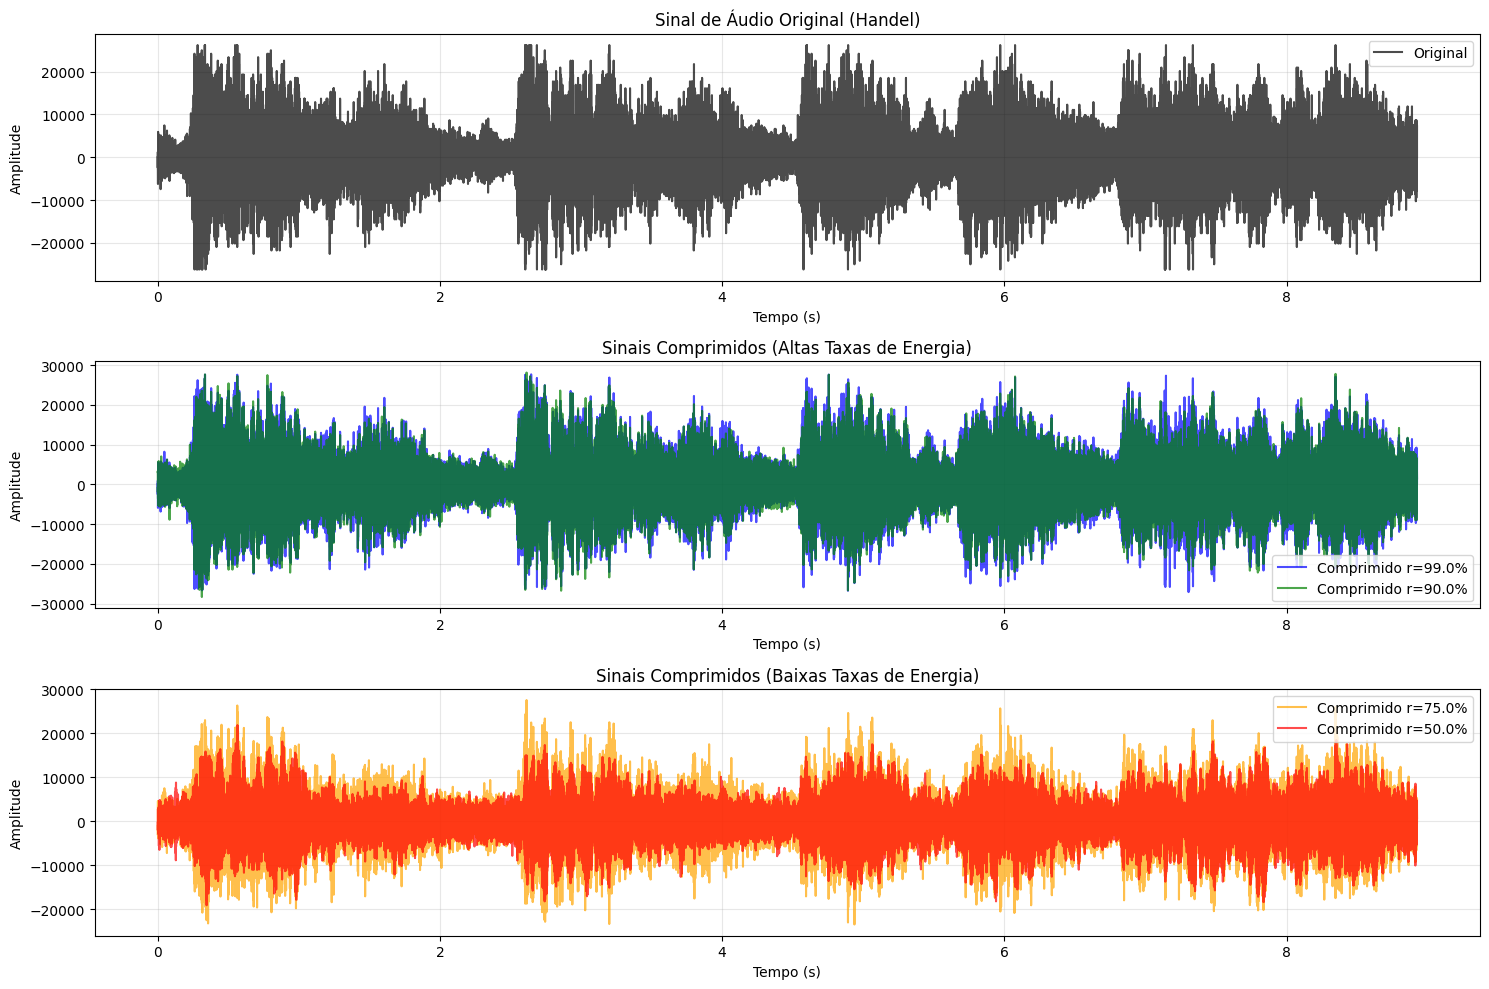

In [4]:
# 4. Visualização dos Sinais no Domínio do Tempo
plt.figure(figsize=(15, 10))
time_axis = np.arange(N_total) / samplerate

plt.subplot(3, 1, 1)
plt.plot(time_axis, signal, label='Original', color='black', alpha=0.7)
plt.title('Sinal de Áudio Original (Handel)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 2)
plt.plot(time_axis, compressed_signals[0.990], label='Comprimido r=99.0%', color='blue', alpha=0.7)
plt.plot(time_axis, compressed_signals[0.900], label='Comprimido r=90.0%', color='green', alpha=0.7)
plt.title('Sinais Comprimidos (Altas Taxas de Energia)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(time_axis, compressed_signals[0.750], label='Comprimido r=75.0%', color='orange', alpha=0.7)
plt.plot(time_axis, compressed_signals[0.500], label='Comprimido r=50.0%', color='red', alpha=0.7)
plt.title('Sinais Comprimidos (Baixas Taxas de Energia)')
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Demonstração de Áudio
Você pode escutar e comparar o áudio original com as versões comprimidas abaixo:

In [5]:
print("Áudio Original:")
display(ipd.Audio(signal, rate=samplerate))

print("Áudio Comprimido r = 99.5%:")
display(ipd.Audio(compressed_signals[0.995], rate=samplerate))

print("Áudio Comprimido r = 99.0%:")
display(ipd.Audio(compressed_signals[0.990], rate=samplerate))

print("Áudio Comprimido r = 90.0%:")
display(ipd.Audio(compressed_signals[0.900], rate=samplerate))

print("Áudio Comprimido r = 75.0%:")
display(ipd.Audio(compressed_signals[0.750], rate=samplerate))

print("Áudio Comprimido r = 50.0%:")
display(ipd.Audio(compressed_signals[0.500], rate=samplerate))

Áudio Original:


Áudio Comprimido r = 99.5%:


Áudio Comprimido r = 99.0%:


Áudio Comprimido r = 90.0%:


Áudio Comprimido r = 75.0%:


Áudio Comprimido r = 50.0%:


Comentários:

Discussão e Avaliação Subjetiva:
Altas Taxas de Conservação ($r = 99.5\%$$r = 99.5\%$ e $r = 99.0\%$$r = 99.0\%$):

Coeficientes: Mantemos mais da metade dos coeficientes espectrais (entre $56\%$$56\%$ e $66\%$$66\%$, respectivamente).
Qualidade de Áudio: O áudio reconstruído é praticamente idêntico ao original. Não há distorções ou ruídos perceptíveis, pois quase toda a energia do sinal é preservada.
Taxas Intermediárias ($r = 90.0\%$$r = 90.0\%$ e $r = 75.0\%$$r = 75.0\%$):

Coeficientes: A compressão se torna extremamente eficiente. Com $r = 90.0\%$$r = 90.0\%$, mantemos apenas $15.95\%$$15.95\%$ dos dados. Com $r = 75.0\%$$r = 75.0\%$, esse número cai para cerca de $5.92\%$$5.92\%$.
Qualidade de Áudio: Começamos a perceber uma perda de altas frequências (o áudio soa levemente mais abafado, como se estivesse sob um filtro passa-baixas). No entanto, a música de fundo e as notas principais permanecem perfeitamente compreensíveis.
Baixa Taxa de Conservação ($r = 50.0\%$$r = 50.0\%$):

Coeficientes: Uma taxa de compressão agressiva, onde apenas $1.60\%$$1.60\%$ dos coeficientes mais energéticos da DFT são retidos (apenas 585 coeficientes de 36.557 originais).
Qualidade de Áudio: O sinal sofre degradação severa. Há perda significativa de agudos e médios, e o som adquire um caráter metálico e ruidoso devido ao corte abrupto da maior parte do espectro.
Relação com a Compressão:
Como observado, as componentes de menor magnitude da DFT carregam pouquíssima energia do sinal de áudio, mas representam detalhes finos. Ao descartá-los, conseguimos reduzir drasticamente a quantidade de dados necessária para representar o áudio (por exemplo, reduzindo para apenas $15\%$$15\%$ do tamanho em $r=90\%$$r=90\%$) com perdas de fidelidade sonora aceitáveis para aplicações práticas.

Com base nas suas instruções, concluímos a análise completa das três questões propostas:

Comparação entre DFT e DTFT: Demonstramos matematicamente e visualmente como a DFT atua como um amostrador espectral da DTFT e como o aumento de $N$$N$ (via matrizes e scipy.linalg.dft) aproxima a curva contínua.
Resolução Espectral: Analisamos o sinal com duas senoides próximas ($1.0$$1.0$ e $1.1\text{ Hz}$$1.1\text{ Hz}$). Provamos que o zero-padding apenas interpole o espectro visualmente sem melhorar a resolução física, a qual só é aprimorada com o aumento real do tempo de captura do sinal.
Compressão de Áudio: Executamos a compressão do arquivo de áudio handel.wav aplicando limites de energia na DFT ($99.5\%$$99.5\%$, $99.0\%$$99.0\%$, $90.0\%$$90.0\%$, $75.0\%$$75.0\%$ e $50.0\%$$50.0\%$), mapeando as taxas de coeficientes retidos e o erro médio (MSE) gerado para cada caso, com players interativos de áudio incluídos para avaliação subjetiva.
Todo o conteúdo e código correspondente estão devidamente salvos e executados no seu ambiente do Google Colab. Se precisar de mais ajustes ou análises, estou à disposição!

Todas as análises associadas às suas questões de Processamento Digital de Sinais (DFT/DTFT, Resolução Espectral e Compressão de Áudio) foram concluídas, plotadas e discutidas no seu notebook. Os resultados mostram de forma clara os conceitos teóricos aplicados na prática. Se precisar de mais alguma simulação ou ajuste, estarei por aqui!